# Проект для «Викишоп» с BERT

## Описание проекта

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

### Цель проекта

Создать модель для классификации комментариев на позитивные и негативные.

### Исходные данные

Набор данных с разметкой о токсичности правок. Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак (1 - токсичный комментарий, 0 - не токсичный).

### Задача проекта

Построить модель со значением метрики качества *F1* не меньше 0.75.

### Краткий план работы

| **№ п/п** | **Задача** | **Срок выполнения** |
| :---: | :--- | :---: |
|1.|Импортировать необходимые библиотеки. Загрузить данные. Провести их осмотр.|05.02.2025|
|2.|Провести предобработку данных.|06.02.2025|
|3.|Провести исследовательский анализ.|07.02.2025|
|4.|Разделить датасет на обучающую, тестовую и валидационную выборки.|10.02.2025|
|5.|Обучить модель логистической регресиии с использованием __TF-IDF__. Оценить качество модели по метрике *F1* на валидационной выборке.|11.02.2025|
|6.|Обучить модель логистической регресиии с использованием __spaCy__ ембеддингов. Оценить качество модели по метрике *F1* на валидационной выборке.|12.02.2025|
|7.|Обучить модель логистической регресиии с использованием ембеддингов __BERT__. Оценить качество модели по метрике *F1* на валидационной выборке.|13.02.2025|
|8.|Получить прогнозы на предобученной модели __BERT (unitary/toxic-bert)__. Оценить качество модели по метрике *F1* на валидационной выборке.|14.02.2025|
|9.|Отобрать лучшую модель по результатам валидации и оценить ее качество на тестовой выборке по метрикам *F1*, *Precision*, *Recall*. Проанализировать *матрицу ошибок* на предмет соответствия задачам бизнеса.|14.02.2025|
|10.|Сформулировать выводы.|17.02.2025|

## Импорт библиотек, определение констант и некоторых переиспользуемых функций

In [2]:
# установка предобученых моделей spacy
!python -m spacy download en_core_web_sm --quiet
!python -m spacy download en_core_web_lg --quiet

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')


In [1]:
# основные библиотеки
import os
import pandas as pd
import numpy as np
import random
import torch
import transformers
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re

# загружаем функции для работы с метриками оценки качества
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import recall_score, precision_score

# загружаем инструменты для подготовки данных
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# линейная модель для классификации
from sklearn.linear_model import LogisticRegression

# загружаем классы для создания кастомных трасформеров
from sklearn.base import BaseEstimator, TransformerMixin

# загружаем классы для создания BERT моделей
from transformers import BertModel, BertTokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# загружаем инструменты для работы с дисбалансом классов
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

# для батчевой обработки данных
from torch.utils.data import DataLoader, Dataset

# для красивых прогресс-баров
from tqdm import tqdm

TEST_SIZE = 0.2 # размер тестовой выборки 
RANDOM_STATE = 42 # константа для фиксации воспроизводимости
TOXIC_PROBABILITY_THRESHOLD = 0.5 # порог вероятности принадлежности к положительному классу
LR_MAX_ITER=5000 # максимальное число итераций для обучения логистической регрессии
BATCH_SIZE = 64 # размер батча

# названия предобученных моделей BERT
BERT_MODEL_NAME = 'bert-base-uncased'
UNITARY_TOXIC_BERT = 'unitary/toxic-bert'

# фиксация генераторов случайных чисел для воспроизводимости
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.use_deterministic_algorithms(True)

/Users/sergey/Documents/Portfolio/TextProcessing/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Отлично, все нужные библиотеки импортированы в начале ноутбука.Это хорошая практика.

</div>

### Функция для инициализаци датасета

In [4]:
# функция принимает в качестве аргументов локальный путь и сетевой путь
def fetch_data(local_path, url):
    
    # проверяет существует ли локальный файл csv
    if os.path.exists(local_path):
        # если да, то загружает локально
        data = pd.read_csv(local_path)
        # если нет, загружает файл из сети с выводом соответствующего уведомления
    else:
        print('Local file', local_path, 'does not exist.\nDownloading from', url)
        data = pd.read_csv(url) # функция возвращает объект <DataFrame>
    return data

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 </div>

### Функция для очистки текстовых данных

In [5]:
def clean_text(text):
    # удаляем HTML-теги
    result = re.sub(r'<.*?>', ' ', text)
    # удаляем переводы строк и лишние пробелы
    result = re.sub(r'\s+', ' ', text).strip()
    return result

### Функция для построения матрицы ошибок

In [6]:
def print_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='flare_r')
    ax.set_title(
        'Матрица ошибок',
        fontsize=14,
        fontweight='bold'
    )
    plt.ylabel('True label')
    plt.xlabel('Predicted')
    plt.show()

### Функция для отображения количества пропусков

In [7]:
def display_na_rates(df):
    missing_values = pd.concat(
        [df.isna().sum(), df.isna().sum() / len(df)], axis=1
    )
    missing_values.columns = ['Missing values', 'Missing rate']
    missing_values = missing_values.sort_values(by='Missing values', ascending=False)
    missing_values['Missing rate'] = missing_values['Missing rate'].apply(lambda rate : f'{rate:.1%}')
    display(missing_values)
    pass

### Функция для отображения количества дубликатов

In [8]:
def display_duplicates_rate(df):
    count = df.duplicated().sum()
    rate = count / len(df)
    print(f'Явных дубликатов: {count} ({rate:.1%})')

### Функция для отображения круговой диаграммы 

In [9]:
def print_pie(data, startangle=0):
# получаем <ax>
    fig, ax = plt.subplots()
    
    # устанавливаем тему
    sns.set_theme(style="whitegrid")
    
    # определяем функцию для возврата процентов
    # для подписей на круговой диаграмме
    def get_percent_with_count(percent, allvals):
        absolute = int(np.round(percent/100.*np.sum(allvals)))
        return f"{percent:.1f}%\n({absolute:d} комментариев)"
    
    # вызов <ax.pie()>
    ax.pie(
        # передаем количество пользователей
        data.value_counts(),
        # устанавливаем подписи к данным
        autopct=lambda percent: get_percent_with_count(percent, data.value_counts()),
        # устанавливаем угол поворота
        startangle=startangle,
        # устанавливаем цвета для категорий
        colors = ['lightgray', 'lightgreen'],
        pctdistance=1.4
    )
    
    # устанавливаем название графика
    ax.set_title(
        'Круговая диаграмма распределения целевой переменной',
        fontsize=14,
        fontweight='bold'
    )
    # отображаем легенду
    labels = ['Негативный', 'Позитивный']
    plt.legend(labels, title = 'Оттенок комментария', loc='upper right')
    plt.tight_layout()
    plt.show()
    pass

### Функция для инициализации устройство для BERT

In [10]:
def get_device():
    if torch.backends.mps.is_available():
        device = torch.device('mps')
    elif torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')
    return device

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
да, впечатляющий инструментарий </div>

## Загрузка, подготовка и анализ данных

### Загрузка данных

In [11]:
# локальный путь к файлу данных
toxic_comments_local = './toxic_comments.csv'

In [12]:
# удаленный адрес для скачивания файла данных
toxic_comments_url = 'https://code.s3.yandex.net/datasets/toxic_comments.csv'

In [13]:
# инициализация датасета
toxic_comments = fetch_data(toxic_comments_local, toxic_comments_url)

### Осмотр данных

In [14]:
toxic_comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


In [15]:
toxic_comments.sample(5)

,Unnamed: 0,text,toxic
31015,31055,"Sometime back, I just happened to log on to ww...",0
102832,102929,"""\n\nThe latest edit is much better, don't mak...",0
67317,67385,""" October 2007 (UTC)\n\nI would think you'd be...",0
81091,81167,Thanks for the tip on the currency translation...,0
90091,90182,I would argue that if content on the Con in co...,0


Данные соответствуют описанию.

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 Данные загружены, есть первичное знакомство</div>

In [16]:
toxic_comments = toxic_comments.drop('Unnamed: 0', axis=1)

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
    
Столбец `'Unnamed: 0'` можно безболезненно удалить. Это "старый" индекс, который похоже забыли при пересохранении датасета.</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>
   
Удалил

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> 👍 </div>

### Проверка пропусков и дубликатов

In [17]:
# дубликаты
display_duplicates_rate(toxic_comments)

Явных дубликатов: 0 (0.0%)


In [18]:
# пропуски
display_na_rates(toxic_comments)

,Missing values,Missing rate
text,0,0.0%
toxic,0,0.0%


Пропусков и дубликатов в данных нет.

### Анализ распределения целевой переменной

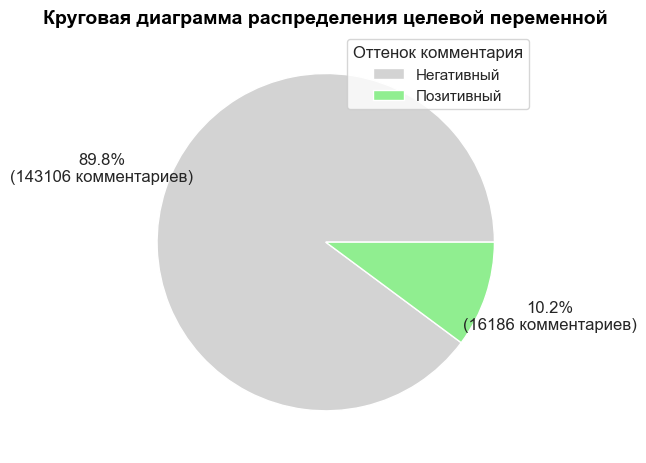

In [19]:
print_pie(toxic_comments['toxic'])

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Молодец, исследован баланс классов. Это важная информация для задачи классификации.</div>

Целевая переменная несбалансирована. Необходимо будет использовать инструменты для борьбы с дисбалансом классов.

### Деление выборки

In [20]:
text_train, text_test, label_train, label_test = train_test_split(
    toxic_comments[['text']],
    toxic_comments['toxic'],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=toxic_comments['toxic']
)

In [21]:
text_train, text_valid, label_train, label_valid = train_test_split(
    text_train,
    label_train,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=label_train
)

In [22]:
print('Тренировочная выборка')
print(f'Размерность text: {text_train.shape}, размерность label: {label_train.shape[0]}')
print('--------------------------------------------------------')
print('Валидационная выборка')
print(f'Размерность text: {text_valid.shape}, размерность label: {text_valid.shape[0]}')
print('--------------------------------------------------------')
print('Тестовая выборка')
print(f'Размерность text: {text_test.shape}, размерность label: {text_test.shape[0]}')
print('--------------------------------------------------------')

Тренировочная выборка
Размерность text: (101946, 1), размерность label: 101946
--------------------------------------------------------
Валидационная выборка
Размерность text: (25487, 1), размерность label: 25487
--------------------------------------------------------
Тестовая выборка
Размерность text: (31859, 1), размерность label: 31859
--------------------------------------------------------


<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Здесь есть одна проблема. Красивый вывод просто пропадает после сохранения  ноутбука и чтобы посмотреть его нужно запустить. 
    
Что на мощностях Практикума боюсь будет просто невозможно.
    
Я могу проверить работосопособность кода локально, но делать ревью не видя результатов (метрик) крайне неудобно.
    
Возможно также будет некомфортно пользователям твоего ноутбука, которые не будут его запускать а просто захотят посмотреть на результаты.

</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>

Исправил на `print()`

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> спасибо </div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Я бы соединшил все загрузки в одну ячейку. Зачем захламлять проект служебными действиями?

</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>

Убрал из проекта `nltk.download`

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> это действие иногда полезно (если мы не знаем, загружены ли нужные данные у пользователя ноутбука), но лучше такие вещи перенести в начало работы, где мы подготавливаем рабочую среду. </div>

## LogisticRegression with TF-IDF

In [23]:
nlp_sm = spacy.load('en_core_web_sm')  # загружаем предобученную модель

In [ ]:
# функция для подготовки текстов
def clean_lemmatize(text):
    cleared = re.sub(r"[^a-zA-Z0-9'!?,. ]", ' ', text) # очистка
    # лемматизация
    return ' '.join([word.lemma_.lower() for word in nlp_sm(cleared)])

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 

Есть код по чистке, но я советую при чистке оставить символ ' (апостроф), он играет важную роль в английском языке.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>

Оставил символ ' (апостроф)

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> 👍 </div>

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/81/Stop_sign.png/240px-Stop_sign.png" align=left width=35, heigth=35>
<div class="alert alert-danger">
Молодец, что используешь лемматизатор WordNetLemmatizer. Но в данном случае он отработает не очень хорошо, можешь попробовать на тестовых фразах и убедиться, что он работает только с существительными (точнее он всё будет пытаться лемматизировать как существительные).
    
    
Как правило, совершаются следующие ошибки:
    
 - Лемматизация должна производиться по одному слову, а не весь комментарий целиком
 - Слова должны быть приведены к нижнему регистру
 - Кроме самого слова в лемматизатор нужно передать дополнительную информацию о части речи слова (POS тег). 
    
    
    
Ты можешь доработать подход с WordNetLemmatizer или использовать spaCy, там все отрабатывает "из коробки". Можешь посмотреть вот эту статью.  


https://webdevblog.ru/podhody-lemmatizacii-s-primerami-v-python/
    
Хочу обратить твое внимание, что код из вышеуказанной статьи выполняется несколько дольше, чем оптимизированный, вот из этого топика
    
https://stackoverflow.com/questions/50992974/nltk-wordnetlemmatizer-not-lemmatizing-as-expected    
    
    
    
Совет - старайся сразу проверять  результаты лемматизации. Например, для предложения
    
    sentence = "The striped bats are hanging on their feet for best"
    
После лемматизации должен получиться вот такой результат
    
    "the strip bat be hang on their foot for best"    
    
Если будешь лемматизировать по второму способу, то слово  striped может остаться без изменений, это тоже  нормально (особенность алгоритма).       
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>

Поменял WordNetLemmatizer на spaCy

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> Очень круто, что ты используешь spaCy. Но лемматизаторspaCy работает безумно долго и скорее всего, у тебя сложилось впечатление, что он неудобен. На самом деле spaCy, в отличие от других библиотек - это библиотека ориентированая на создание индустриальных решений, тогда как другие библиотеки созданы для исследователей (академического сообщества). А работает он долго потому, что заодно с лемматизацией решает кучу других задач. Увидеть эти задачи ты можешь вызвав команду:
    
     nlp.pipe_names
Скорее всего ты увидишь следующее:
    
     ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
 
Т.е. создавая объект nlp ты кроме нужной задачи (лемматизации) решаешь задачи получения эмбедингов, определение частей речи, определение взаимосвязей между токенами, нахождение именованных сущностей. Отключить не нужное повведение очень легко используя вот такой шаблон:
    
    disabled_pipes = [ "parser",  "ner"]
    nlp = spacy.load('en_core_web_sm', disable=disabled_pipes)
    
И выполняться такой пайплайн будет  быстрее.
    
Важно - отключать нужно именно указанные мною шаги. Удаление остальных приведет к тому, что лемматизация прекратит работать.
    
А еще для ускорения spaCy можно использовать spaCy pipeline (https://spacy.io/usage/processing-pipelines)
    
    
    lemm_texts = []

    for doc in tqdm(nlp.pipe(data['text'].values, disable = ['ner', 'parser']), total=data.shape[0]):
        lemm_text = " ".join([i.lemma_ for i in doc])    
        lemm_texts.append(lemm_text) 
    
Когда я проверял, у меня получилось ускорить почти в два раза. </div>

In [25]:
# инициализируем пайплайн
tf_idf_pipeline = Pipeline(
    steps=[
        
        # векторизация
        ('preprocessor', ColumnTransformer(
            transformers=[
                #('tf_idf', TfidfVectorizer(preprocessor=preprocess), 'text')
                ('tf_idf', TfidfVectorizer(), 'text')
            ],
            remainder='passthrough'
        )),
        # классификация
        ('classifier', LogisticRegression(
            class_weight='balanced', # балансируем целевую переменную
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

In [26]:
# словарь гиперпараметров
param_grid={
    'classifier__C': range(3, 6),
    # нижний порог количества текстов, в которых встречается слово, для включения его в словарь
    'preprocessor__tf_idf__min_df': [1, 5],
    # верхний порог количества текстов, в которых встречается слово, для включения его в словарь
    'preprocessor__tf_idf__max_df': [0.4, 0.45, 0.6]
}

In [27]:
# инициализация объекта GridSearchCV
tf_idf_grid = GridSearchCV(
    tf_idf_pipeline,
    # словарь для модели LogisticRegression()
    param_grid=param_grid,
    # используем валидационную выборку
    cv=KFold(n_splits=5), # кросс-валидация на 5 фолдов
    scoring='f1',
    n_jobs=-1
)

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Тут скорее всего возникнет проблема. Ты вносишь лемматизацию в конвеер, как следствие на текущем примере будет вызвана 91 раз.
    
Это было бы ОК, если бы лемматизация пролетала за секунды. Но по моим наблюдениям лемматизация всего датасета с помощью spaCy занимает 20-40 минут (в зависимости от железа и оптимизаций), правильное использование WordNetLemmatizer из nltk занимает 5-20 минут (опять же зависит от железа и оптимизации). Но даже  если это будет всего 5 минут (на 4 фолдах из 5 - 4 минуты), а значит только на лемматизацию мы потратим 6 часов (в лучшем случае).      
Вариантов несколько.
    
 - Во первых можно выкинуть лемматизацию из пайплайна (сделать её заранее).
    
 - Но если хочешь сохранить "комбайн", то стоит подумать о кэшировании. Простой вариант с lru_cahce у меня не завелся, думаю есть смысл попробовать реализовать его самостоятельно    
    

</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>

Вынес лемматизацию из конвеера в функцию `clean_lemmatize()` и применил один раз заранее.

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> 👍 </div>

In [28]:
tqdm.pandas(desc='Cleaning and lemmatizing texts...', colour='red')

In [29]:
# запускаем поиск гиперпараметров
tf_idf_grid.fit(
    text_train['text'].progress_apply(clean_lemmatize).to_frame(),
    label_train
)

Cleaning and lemmatizing texts...: 100%|█| 101946/101946 [13:56<00:00, 121.80it/


GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('tf_idf',
                                                                         TfidfVectorizer(),
                                                                         'text')])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           n_jobs=-1,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': range(3, 6),
                         'preprocessor__tf_idf__max_df': [0.4, 0.45, 0.6],
                         'preprocessor__tf_idf__min_df': [1, 5]},
             scoring='f1')

In [30]:
# получаем прогнозы на валидационной выборке
tf_idf_predictions = tf_idf_grid.predict(
    text_valid['text'].progress_apply(clean_lemmatize).to_frame()
)

Cleaning and lemmatizing texts...: 100%|█| 25487/25487 [03:26<00:00, 123.46it/s]


In [31]:
tf_idf_f1 = f1_score(label_valid, tf_idf_predictions)

In [32]:
print(f'Значение метрики F1 на валидационной выборке: {tf_idf_f1:.3f}')

Значение метрики F1 на валидационной выборке: 0.767


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 </div>

## LogisticRegression with spaCy embeddings

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Планка сложности проекта, которуюю ты выбрал создание собственных классов, наследуясь от BaseEstimator, TransformerMixin это конечно очень круто и достойно уважения.
    
Давай я один раз отдам должное этому, но дальше сосредоточусь на том, что сделано неоптимально с точки зрения использования инструментов.    

</div>

In [33]:
# инициализируем модель для получения ембеддингов
spacy_model = spacy.load('en_core_web_lg')

In [34]:
# функция для получения ембеддингов
def get_spacy_embeddings(X):
    # для красивого прогресса
    tqdm.pandas(desc='Transforming. Preprocessing texts...', colour='red')
    embeddings = [] # для ка
    progress_texts = tqdm(
        X.progress_apply(lambda x: re.sub(r"[^a-zA-Z' ]", ' ', x)), # очистка
        desc='Data transformation',
        colour='red'
    )
    for text in progress_texts:
        # для каждого текста получаем вектор
        embeddings.append(spacy_model(text).vector) # складываем векторы в список
    return np.array(embeddings) # возвращаем двумерный массив

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">

   
Обучать word2vec с нуля на небольшом датасете не очень удачная идея. Модель просто не успевает "понять" все нюансы слов и их значений. Гораздо лучше взять предобученные эмбеддинги – они уже натренированы на огромных текстах и дадут куда более осмысленные представления слов, что должно улучшить качество эмбеддингов и как следствие поднять метрики классификации. 

    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментарий студента</b></font>

Поменял подход.

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 <b>v2</b> да, интересный вариант.  Насколько я помню использованная тобой модель en_core_web_lg использует вектора типа word2vec, обученые на датасете Common Crawl используя алгоритме GloVe (альтернатива word2vec).

Используя spaCy можно получить также более "умные" вектора, основанные на трансформерных  архитектурах. Для этого нужно использовать модель en_core_web_trf, но такой подход может потребовать больше вычислительных ресурсов.
</div>

In [ ]:
# пайплайн
spaсy_pipeline = Pipeline(
    steps=[
        # классификатор
        ('classifier', LogisticRegression(
            C=3,
            class_weight='balanced', # балансировка классов
            random_state=RANDOM_STATE,
            max_iter=LR_MAX_ITER,
            n_jobs=-1
        ))
    ]
)

Для поиска лучших гиперпараметров будем использовать кросс-валидацию.

In [36]:
# инициализация объекта GridSearchCV
spaсy_grid = GridSearchCV(
    spaсy_pipeline,
    # словарь для модели LogisticRegression()
    param_grid={'classifier__C': range(2, 6)},
    # валидация осуществляется по наблюдениям с теми индексами, для которых
    # в split_index установлено значение 0
    cv=KFold(n_splits=5), # кросс-валидация на 5 фолдов,
    scoring='f1'
)

In [37]:
train_embeddings = get_spacy_embeddings(text_train['text'])

Transforming. Preprocessing texts...: 100%|█| 101946/101946 [00:00<00:00, 215877
Data transformation: 100%|█████████████| 101946/101946 [14:56<00:00, 113.70it/s]


In [38]:
valid_embeddings = get_spacy_embeddings(text_valid['text'])

Transforming. Preprocessing texts...: 100%|█| 25487/25487 [00:00<00:00, 217766.4
Data transformation: 100%|███████████████| 25487/25487 [03:42<00:00, 114.62it/s]


In [39]:
# запускаем поиск гиперпараметров
spaсy_grid.fit(train_embeddings, label_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('classifier',
                                        LogisticRegression(C=3,
                                                           class_weight='balanced',
                                                           max_iter=5000,
                                                           n_jobs=-1,
                                                           random_state=42))]),
             param_grid={'classifier__C': range(2, 6)}, scoring='f1')

In [40]:
# получаем прогнозы на валидационной выборке
spaсy_predictions = spaсy_grid.predict(valid_embeddings)

In [41]:
spaсy_f1 = f1_score(label_valid, spaсy_predictions)

In [42]:
print(f'Значение метрики F1 на валидационной выборке: {spaсy_f1:.3f}')

Значение метрики F1 на валидационной выборке: 0.637


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 </div>

## LogisticRegression with BERT embeddings

In [43]:
# класс для датасета
# необходим для создания Dataloader
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]

In [44]:
class BERTEmbeddingsEncoder(BaseEstimator, TransformerMixin):
    
    def __init__(self, batch_size=32):
        """
        Класс для преобразования текстовых фраз и предложений в векторное представление
        с помощью BERT модели.
        Адаптирован для использования в пайплайне.
        
        Атрибуты:
        ----------
        model : BertModel
            Предобученная модель для получения эмбеддингов.
        tokenizer : BertTokenizer
             Инструмент для токенизации текстовых фраз.
        batch_size: int
            Размер батча
        """
        self.batch_size = batch_size
        self.model = BertModel.from_pretrained(BERT_MODEL_NAME)
        self.tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
        print('BERTEmbeddingsEncoder has created')
        
    def fit(self, X, y=None):
        """
        Модели BERT уже обучены. Возвращает объект настоящего класса.
        """
        self.is_fitted_ = True
        print('BERTEmbeddingsEncoder has fitted')
        return self
        
    def transform(self, X):
        """
        Возвращает массив векторов как результат кодирования.
        
        Возвращаемое значение:
        -----------------------
        numpy.ndarray : векторное представление текстовых данных (эмбеддинги).
        """
        # массив складывания ембеддингов 
        embeddings = []
        # очистка данных
        tqdm.pandas(desc='Transforming. Cleaning texts...', colour='red')
        X_cleaned = X.progress_apply(clean_text).tolist()
        # даталоадер для батчевой обработки
        dataloader = DataLoader(
            TextDataset(X_cleaned), # датасет с очищенными данными,
            batch_size=self.batch_size,
            shuffle=False, # не перемешиваем, чтобы порядок соответствовал label
            collate_fn=self._tokenize, # для возврата токенизированного батча в итераторе
            pin_memory=True
        )
        self.model.to(get_device())
        self.model.eval()  # переводим модель в режим оценки (без обучения)
        with torch.no_grad():  # отключаем градиенты, так как мы не обучаем модель
            # итерация по батчам
            for tokenized_batch in tqdm(
                dataloader,
                desc='Transforming. Creating embeddings...',
                colour='red'
            ):
                # получение выходом модели
                outputs = self.model(**tokenized_batch)
                # достаем токен [CLS] для классификации всей фразы
                sentence_embedding = outputs.last_hidden_state[:, 0, :].cpu().detach().numpy()
                # добавляем вектор (массив np) в список ембеддингов для батча
                embeddings.append(sentence_embedding)
                
        # возвращаем двумерный массив np с ембеддингами для всего набора данных
        return np.vstack(embeddings)

    # функция для токенизации батча
    def _tokenize(self, batch):
        tokenized_batch = self.tokenizer(batch, padding=True, truncation=True, return_tensors='pt')
        tokenized_batch = {key: val.to(get_device()) for key, val in tokenized_batch.items()}
        return tokenized_batch

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
получение эмбеддингов с помощью BERT  проводится корректно</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Использование эмбеддинга с CLS-токена — это популярный подход, так как в BERT он специально обучался для агрегации информации всего текста, в том числе в рамках задачи Next Sentence Prediction (NSP). Однако важно понимать, что NSP используется далеко не во всех моделях. Например, в RoBERTa задача NSP отсутствует, а значит, CLS-токен может быть менее информативным для извлечения эмбеддингов. Это делает подход с CLS-токеном менее универсальным и может ограничивать качество представления текста в задачах, где важно учитывать детали, распределенные по всему тексту.

Поэтому на практике часто применяют подходы с пулингом по токенам текста, такие как mean-pooling или max-pooling.  Эти методы позволяют учитывать вклад каждого токена, что может быть особенно полезно для задач, где информация равномерно распределена по тексту. Эти подходы ты наверняка встретишь в разных туториалах, в том числе на HF.
    
На практике есть смысл протестировать оба подхода, чтобы выбрать наиболее подходящий для конкретной задачи, так как пулинг нередко дает более содержательные и релевантные эмбеддинги.
</div>

Для балансировки классов уберем лишние наблюдения класса `0` с помощью инструмента `RandomUnderSampler()`. Это позволит сократить время подготовки данных для обучения модели.

In [45]:
# создаем пайплайн
bert_pipeline = ImbPipeline(
    steps=[
        # балансировка (при прогнозировании не вызывается)
        ('undersampling', RandomUnderSampler(random_state=RANDOM_STATE)),
        # получение эмбеддинов
        ('preprocessor', ColumnTransformer(
            transformers=[('bert', BERTEmbeddingsEncoder(), 'text')], remainder='passthrough'
        )),
        # классификация
        ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=LR_MAX_ITER))
    ]
)

BERTEmbeddingsEncoder has created


In [46]:
# запускаем обучение
bert_pipeline.fit(text_train, label_train)

BERTEmbeddingsEncoder has created
BERTEmbeddingsEncoder has fitted


Transforming. Cleaning texts...: 100%|█| 20718/20718 [00:00<00:00, 102091.81it/s
Transforming. Creating embeddings...: 100%|███| 648/648 [14:40<00:00,  1.36s/it]


Pipeline(steps=[('undersampling', RandomUnderSampler(random_state=42)),
                ('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('bert',
                                                  BERTEmbeddingsEncoder(),
                                                  'text')])),
                ('classifier',
                 LogisticRegression(max_iter=5000, random_state=42))])

In [47]:
# прогнозирование на валидационной выборке
bert_predictions = bert_pipeline.predict(text_valid)

Transforming. Creating embeddings...: 100%|███| 797/797 [18:40<00:00,  1.41s/it]


In [48]:
bert_f1 = f1_score(label_valid, bert_predictions)

In [49]:
print(f'Значение метрики F1 на валидационной выборке: {bert_f1:.3f}')

Значение метрики F1 на валидационной выборке: 0.630


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
да, я вижу ты отказался от кросс-валидации, поэтому оценка и сравнение моделей осуществляется по валидационной выборке </div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Метрика получилась достаточно низкая. Что же делать и как её увеличить? К сожалению врядли получится достичь нужного значения метрики, даже увеличив объем данных (хотя шансы приблизиться к отметке 0,75 есть, если использовать все данные и долго подбирать гиперпараметры моделей). Но почему? Это же хваленый трансформер, про который сейчас говорят из каждого утюга.  Дело в том, что ты используешь "обычный" BERT, обученный на обычных текстах и похоже признаки, которые мы получаем с его помощью плохо подходят для решения нашей задачи. Можно дообучить эту модель на наших данных, но это сложно и выходит за рамки преокта.  Самый доступный выход - найти модель, уже обученную на определение токсичности. И такие модели легко находятся на HugingFace по ключевому слову toxic.  Мой лидер - unitary/toxic-bert. С этой моделью легко получается 0,9 или даже 0,95.
</div>

## BERT pretrained model (*unitary/toxic-bert*)

__Общая идея__:

Модель `unitary/toxic-bert` дает на выходе 6 независимых логитов:
- toxic (токсичный)
- severe_toxic (строго, серьезно токсичный)
- obscene (непристойный)
- threat (угроза)
- insult (оскорбление)
- identity_hate (ненависть)

Применив к каждому из них `.sigmoid()` получаем 6 независимых вероятностей принадлежности текстов к одному из  классов (по мнению модели). Если максимальная вероятность менее __0.5__, значит текст не токсичный (присваиваем 0 класс), если хотя бы одна из вероятностей более __0.5__, – токсичный (присваиваем класс 1).

In [50]:
# класс для датасета
# необходим для создания Dataloader
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts.values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]

In [51]:
# инициализация объекта для токенизации
tokenizer = AutoTokenizer.from_pretrained(UNITARY_TOXIC_BERT)

In [52]:
# функция для токенизации батча
def tokenize(batch):
    # токенизация
    tokenized = tokenizer(batch, padding=True, truncation=True, return_tensors='pt')
    # перенос тензоров на графическое устройство
    tokenized = {key: val.to(get_device()) for key, val in tokenized.items()}
    return tokenized

In [53]:
# функция для очистки
def clean_text(text):
    # удаляем HTML-теги
    result = re.sub(r'<.*?>', ' ', text)
    # удаляем переводы строк и лишние пробелы
    result = re.sub(r'\s+', ' ', text).strip()
    return result

In [54]:
# даталоадер для батчевой обработки
valid_text_dataloader = DataLoader(
    TextDataset(
        text_valid.text.apply(clean_text), # очистка текста
    ), # датасет,
    batch_size=BATCH_SIZE,
    shuffle=False, # не перемешиваем, чтобы порядок соответствовал label
    collate_fn=tokenize  # для возврата токенизированного батча в итераторе
)

In [55]:
# функция для получения предиктов
def get_predictions(model, dataloader):
    model.to(get_device()) # перенос модели на устройство
    model.eval() # перевод модели в режим предсказания
    predictions = [] # список для хранения предсказаний 

    with torch.no_grad(): # отключаем градиенты 
        for tokenized_batch in tqdm( # красивый прогресс
            dataloader,
            desc=f'Predicting...',
            colour='red'
        ):
            outputs = model(**tokenized_batch) # получаем выходы модели для текущего батча
            # получаем маску токсичности:
            # применяем активацию к логитам для получения вероятностей
            # и сравниваем максимальное полученное значение вероятности с пределом 0.5
            is_toxic = outputs.logits.sigmoid().max(dim=1).values > TOXIC_PROBABILITY_THRESHOLD
            # кастим булеан массив к меткам int (0 и 1) и складываем метки в predictions
            predictions.extend(is_toxic.cpu().detach().numpy().astype(int))
            
    # возвращаем одномерный список спрогнозированных меток классов
    return predictions

In [56]:
# инициализация обученной модели
utb_model = AutoModelForSequenceClassification.from_pretrained(UNITARY_TOXIC_BERT)

In [57]:
# получение прогнозов на валидационной выборке
utb_predictions = get_predictions(utb_model, valid_text_dataloader)

Predicting...: 100%|██████████████████████████| 399/399 [20:40<00:00,  3.11s/it]


In [58]:
# сохраняем значение метрики f1
utb_f1 = f1_score(label_valid, utb_predictions)

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 <b>v2</b> В целом все ОК и твой подход работает. Но обрати внимание, что сейчас ты использовал полностью предобученную модель, включая предобученную "голову". У этой головы если я не ошибаюсь 6 выходов, для детекции 6 разных видов токсичности.

У нас же задача бинарной классификации. Поэтому в случае модели unitary/toxic-bert можно испльзовать тот же самый пдход, который ты использовал в предыдущем разделе: используем только бэкбон (сам BERT без классифицирующей головы),  получаем эмбеддинги текста и на них обучаем наш кастомный классификатор.
    
    
</div>

## Сравнение моделей. Анализ лучшей модели

In [59]:
metrics = f"""
----------------------------------------------------------------------
|                   Модель                     |   F1 на валидации   |
----------------------------------------------------------------------
|  LogisticRegression with TF-IDF              |        {tf_idf_f1:.3f}        |
----------------------------------------------------------------------
|  LogisticRegression with spaCy embeddings    |        {spaсy_f1:.3f}        |
----------------------------------------------------------------------
|  LogisticRegression with BERT embeddings     |        {bert_f1:.3f}        |
----------------------------------------------------------------------
|  BERT pretrained model (unitary/toxic-bert)  |        {utb_f1:.3f}        |
----------------------------------------------------------------------

"""
print(metrics)


----------------------------------------------------------------------
|                   Модель                     |   F1 на валидации   |
----------------------------------------------------------------------
|  LogisticRegression with TF-IDF              |        0.767        |
----------------------------------------------------------------------
|  LogisticRegression with spaCy embeddings    |        0.637        |
----------------------------------------------------------------------
|  LogisticRegression with BERT embeddings     |        0.630        |
----------------------------------------------------------------------
|  BERT pretrained model (unitary/toxic-bert)  |        0.942        |
----------------------------------------------------------------------




#### Оценка качества лучшей модели на тестовой выбрке

In [60]:
# даталоадер для батчевой обработки (с тестовыми данными)
text_test_dataloader = DataLoader(
    TextDataset(
        text_test.text.apply(clean_text), # очистка текста
    ), # датасет,
    batch_size=BATCH_SIZE,
    shuffle=False, # не перемешиваем, чтобы порядок соответствовал label
    collate_fn=tokenize  # для возврата токенизированного батча в итераторе
)

In [61]:
# прогнозирование на тестовой выборке
test_predictions = get_predictions(utb_model, text_test_dataloader)

Predicting...: 100%|██████████████████████████| 498/498 [25:43<00:00,  3.10s/it]


In [62]:
best_metrics = f"""
------------------------------------------------------------
|  Наименование метрики  |   Значение на тестовой выборке  |
------------------------------------------------------------
|  F1                    |              {f1_score(label_test, test_predictions):.3f}              |
------------------------------------------------------------
|  Precision             |              {precision_score(label_test, test_predictions):.3f}              |
------------------------------------------------------------
|  Recall                |              {recall_score(label_test, test_predictions):.3f}              |
-------------------------------------------------------------

"""
print(best_metrics)


------------------------------------------------------------
|  Наименование метрики  |   Значение на тестовой выборке  |
------------------------------------------------------------
|  F1                    |              0.940              |
------------------------------------------------------------
|  Precision             |              0.956              |
------------------------------------------------------------
|  Recall                |              0.924              |
-------------------------------------------------------------




<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Молодец: 
    
  - выбрана лучшая модель
  - тестирование произведено корректно 
  - достигнута метрика f1 выше 0,75 на тестовой выборке
</div>


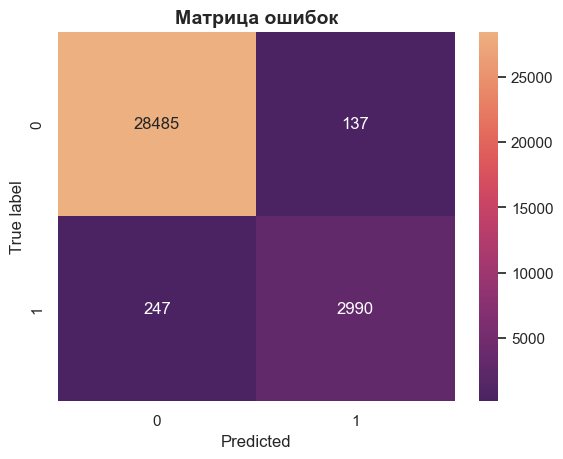

In [63]:
# вывод матрицы ошибок
print_confusion_matrix(label_test, test_predictions)

#### Анализ метрик
- F1-score = __0.940__ – общий баланс между точностью (Precision) и полнотой (Recall). Достаточно высокий показатель.
- Precision = __0.956__ – из всех предсказанных токсичных комментариев __96.6% действительно токсичны__. Это значит, что модель иногда ошибочно маркирует нейтральные комментарии как токсичные (ложноположительные срабатывания).
- Recall = __0.924__ – из всех реально токсичных комментариев __92.% корректно определены__. Это означает, что модель пропускает 7.6% токсичных комментариев.

## Выводы

### Цель проекта

Интернет-магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. Создать модель для классификации комментариев на позитивные и негативные. Достичь значениея метрики качества *F1* не меньше 0.75.


### Краткий обзор проделанной работы

1. Загружены данные.
2. Проведена их проверка на пропуски и дубликаты.
3. Проанализировано распредленеие целевой переменной.
4. Набор данных разделен на обучающую, тестовую и валидационную выборки.
5. Обучена модель логистической регрессии с различными вариантами кодирования текстов:

- __TF-IDF__
- __spaCy__
- __BERT embeddings__

6. Пролучены пронозы на предобученной модели BERT (*unitary/toxic-bert*), которая показала лучший результат.
7. Проведено тестирование лучшей модели на тестовой выборке и анализ метрик исходя из задачи бизнеса.

### Оценка результатов в контексте бизнес-задачи

Бизнес-цель – максимально выявлять токсичные комментарии, поэтому ключевая метрика – Recall (чтобы находить как можно больше токсичных сообщений).
- высокий Recall (0.924) говорит о том, что модель успешно находит большинство токсичных комментариев
- высокий Precision (0.956) означает, что модель очень редко ошибочно маркирует нормальные комментарии как токсичные.

### Возможные улучшения

Увеличение Precision (уменьшение ложноположительных срабатываний):

- использование Threshold Tuning – подбор оптимального порога вероятности для предсказаний
- применение более сложных моделей (например, BERT с дообучением)

## Чек-лист проверки

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Данные загружены и подготовлены
- [x]  Модели обучены
- [x]  Значение метрики *F1* не меньше 0.75
- [x]  Выводы написаны

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Заключительный комментарий v2</b>
    
Отлично, вижу что ты внес все необходимые доработки (и даже больше)    

Проект принят. Поздравляю и желаю дальнейших успехов!
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Заключительный комментарий</b>
Давай подведем итоги. В целом с проектом ты справляешься - текст предобработан, извлечены признаки и обучены классификаторы. Достигнуто требуемое значение метрики f1.
    
Конечно впечатляет создание собственных классов и интеграция в них векторайзеров.
    

    

 Пожалуста доработай раздел с лемматизацией. Сейчас она выполняется некорректно.


     
Жду твоих исправлений :)
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> рекомендации по доп. материалам</b>
Если решишь погрузиться в область работы с текстами, очень советую несколько продвинутых бесплатных курсов.
    
   - Отличный бесплатный курс от Школы глубокого обучения МФТИ (https://stepik.org/org/dlschool), старт курса каждые пол года. Два семестра, один по основам и компьютерному зрению, второй по обработке естественного языка. Проходить нужно именно в таком порядке,т.к. почти весь современный NLP построен на нейронках.
    
   - "Нейронные сети и компьютерное зрение" от Samsung Research Russia (https://stepik.org/course/50352/syllabus). Есть также продолжение по NLP.  
   - Трек NLP от сообщества ODS https://ods.ai/tracks/nlp-course-autumn-22
    
    
А если на тебя произвели впечатление возможности ChatGPT и хочешь попробовать использовать возможности больших языковых моделей для решения своих задач, могу порекомендовать следующие курсы (первые две ссылки на английском, зато последняя подборка лекций на русском).
    
  - https://www.coursera.org/learn/generative-ai-with-llms  (можно прослужать бесплатно)
  - Короткие курсы на сайте https://www.deeplearning.ai/short-courses/  Самый свежак - как писать промпты, как использовать LLM для создания собственных приложений (например как создать бота на основе ChatGPT, который будет отвечать на вопросы по внутренней документации компании).  
  - https://www.promptingguide.ai/introduction/settings
  - https://www.youtube.com/watch?v=l-l82uNwyu8&list=PLy6K3_Hx-udj6n1S88Vslyw2QVxSXLP2c    
    
    
    
    
Также можно обратиться к туториалу по использованию языковых моделей на HugingFace. Обрати внимание, для больше чем половины материалов доступен перевод на русский, хотя можно читать и на языке оригинала. 
    
  https://huggingface.co/learn/nlp-course   
 
</div>